El objetivo es segmentar a los clientes con base a distintas características.

In [1]:
import pandas as pd
import numpy as np
import sqlite3
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
from scipy.stats import chi2_contingency
import mlflow
import mlflow.sklearn 
import os
import plotly.express as px


BASE_DIR = Path.cwd().parent
DB_PATH = BASE_DIR / "data" / "northwind.db"

conn = sqlite3.connect(DB_PATH)

Conexión con la base de datos Northwind hecha.

In [2]:
query = ''' SELECT c.CustomerName as NombreCliente, SUM(od.Quantity) as UnidadesCompradas, sum(od.Quantity * p.Price) AS Monto, 
        count(DISTINCT o.OrderID) as NumeroDeOrdenes, AVG(od.Quantity * p.Price) AS TicketPromedio, 
        c.Country as Pais, COUNT(DISTINCT p.CategoryID) AS DiversidadCategorias FROM Customers c
        JOIN Orders o ON c.CustomerID = o.CustomerID
        JOIN OrderDetails od ON o.OrderID = od.OrderID
        JOIN Products P ON od.ProductID = p.ProductID
        GROUP BY c.CustomerName
        ORDER BY Monto DESC  
'''

dataset = pd.read_sql_query(query, conn)
print(dataset) 

                         NombreCliente  UnidadesCompradas     Monto  \
0                         Ernst Handel               1418  35631.21   
1                       Mère Paillarde                422  23362.60   
2                   Save-a-lot Markets                775  22500.06   
3           Rattlesnake Canyon Grocery                573  18421.42   
4                           QUICK-Stop                839  18178.80   
..                                 ...                ...       ...   
69              Océano Atlántico Ltda.                 24    399.00   
70                     Du monde entier                 13    336.00   
71          Centro comercial Moctezuma                 11    126.00   
72  Ana Trujillo Emparedados y helados                  6    111.00   
73                      Franchi S.p.A.                  2     62.46   

    NumeroDeOrdenes  TicketPromedio       Pais  DiversidadCategorias  
0                10     1018.034571    Austria                     8  
1    

Ya tenemos nuestro data set cargado, ahora hay que verificar que esté limpio.

In [3]:
print(dataset.info())
print(dataset.index.duplicated().any())
print(dataset.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   NombreCliente         74 non-null     object 
 1   UnidadesCompradas     74 non-null     int64  
 2   Monto                 74 non-null     float64
 3   NumeroDeOrdenes       74 non-null     int64  
 4   TicketPromedio        74 non-null     float64
 5   Pais                  74 non-null     object 
 6   DiversidadCategorias  74 non-null     int64  
dtypes: float64(2), int64(3), object(2)
memory usage: 4.2+ KB
None
False
NombreCliente           0
UnidadesCompradas       0
Monto                   0
NumeroDeOrdenes         0
TicketPromedio          0
Pais                    0
DiversidadCategorias    0
dtype: int64


El dataframe está limpio. Ahora como queremos segmentar a nuestros clientes de acuerdo a sus características podemos pensar en algún algoritmo de Machine Learning, en este caso de aprendizaje no supervisado, concretamente de clustering. Como pudimos ver en el EDA varias de estas variables aleatorias tienen múltiples outliers, por lo que algunos modelos que son sensibles a estos pueden verse afectados. En principio DBSCAN debería hacer un buen trabajo con los valores atípicos porque los maneja como ruido aunque si las variables aleatorias están muy correlacionadas pueden influir en el modelo negativamente. Antes de DBSCAN veremos qué tan correlacionadas están entre sí y si es necesario aplicar algún algoritmo PCA para agrupar las variables según que tan relacionadas estén.

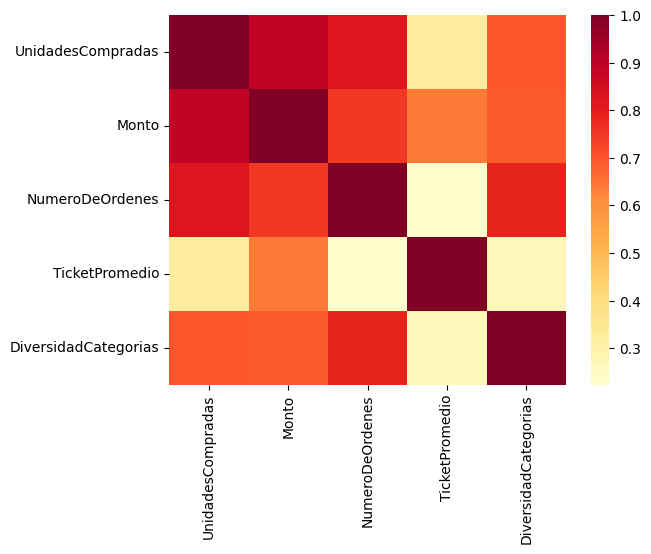

In [4]:
matriz_corr = dataset.corr(numeric_only=True)

sns.heatmap(matriz_corr, cmap="YlOrRd")
plt.show()

En el heatmap podemos observar que la variable Unidades compradas tiene una alta correlación con Monto y con Número de órdenes, esto afectará al modelo pues le dará más peso a la magnitud de compra que a otras categorías. En este escenario es conveniente aplicar un algoritmo de PCA para agrupar estas variables antes de usar DBSCAN.

In [5]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(dataset[["UnidadesCompradas", "Monto", "NumeroDeOrdenes", "TicketPromedio", 
                                         "DiversidadCategorias"]])

df_scaled = pd.DataFrame(x_scaled, columns=["UnidadesCompradas", "Monto", "NumeroDeOrdenes", "TicketPromedio", 
                                         "DiversidadCategorias"], index=dataset.index)

print(df_scaled)


    UnidadesCompradas     Monto  NumeroDeOrdenes  TicketPromedio  \
0            5.612301  4.537269         4.108968        0.648028   
1            1.125334  2.706709         1.314265        1.746056   
2            2.715594  2.578012         0.755325        1.303108   
3            1.805587  1.969451         2.432146        0.343120   
4            3.003914  1.933251         2.432146        0.463942   
..                ...       ...              ...             ...   
69          -0.667651 -0.719617        -0.921496       -0.733165   
70          -0.717206 -0.729017        -0.921496       -0.786318   
71          -0.726216 -0.760350        -0.921496       -0.963495   
72          -0.748741 -0.762588        -0.921496       -0.976150   
73          -0.766761 -0.769831        -0.921496       -0.964406   

    DiversidadCategorias  
0               1.904156  
1               1.904156  
2               1.414893  
3               1.904156  
4               1.904156  
..                   

Escalamos los datos ya que PCA es sensible a las escalas y en esta parte sólo trabajaremos con las variables continuas pues no tiene sentido agregar las categóricas a estos modelos. Más adelante las retomaremos.

In [6]:
mlflow.set_tracking_uri("sqlite:///../mlflow.db")
mlflow.set_experiment("PCA clientes Northwind")

with mlflow.start_run(run_name="PCA 3 Componentes"):
    
    mlflow.log_param("n_components", 3)
    
    pca_model = PCA(n_components=3)
    x_pca = pca_model.fit_transform(df_scaled)

    varianza_total = pca_model.explained_variance_ratio_.sum()

    mlflow.log_metric("Varianza explicada total", varianza_total)
    
    print(varianza_total)
    

2026/01/28 15:02:25 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/01/28 15:02:25 INFO mlflow.store.db.utils: Updating database tables
2026/01/28 15:02:25 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/01/28 15:02:25 INFO alembic.runtime.migration: Will assume non-transactional DDL.
2026/01/28 15:02:28 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/01/28 15:02:28 INFO alembic.runtime.migration: Will assume non-transactional DDL.


0.9612970948749269


Realizamos el entrenamiento, probamos los hiperparámetros y registramos el tracking en MLflow para medir el rendimiento de cada componente en forma de Varianza explicada. Obtuvimos que que la Varianza explicada de 2 componentes fue de .894, de 3 componentes de .961, de 4 componentes de .993, lo cual es un comportamiento esperado, que al agregar componentes se gane información aunque para elegir el número de componentes notemos que al pasar de 2 a 3 componentes ganamos 6.7% de varianza explicada. Por otro lado, al pasar de 3 a 4 componentes sólo ganamos 3.2%. Esto nos dice que el tercer componente aún aporta información útil, mientras que el 4 componente sólo agrega detalles muy específicos o ruido y por el Principio de Parsimonia buscamos el modelo más sencillo que aporte mayor información. Por lo tanto, el mejor modelo es el que usa 3 componentes. (Las capturas de las runs están en la carpeta docs)

In [7]:
df_pca = pd.DataFrame(x_pca, columns=["PC1", "PC2", "PC3"], index=dataset.index)

fig = px.scatter_3d(df_pca, x='PC1', y='PC2', z='PC3', title='Mapa 3D de Clientes Northwind (PCA)', opacity=0.7,             
    template='plotly_dark', width=800, height=600)

fig.update_traces(marker=dict(size=4))

fig.show()

Podemos ver en la gráfica que tenemos una nube grande cercana a (0, 0, 0). Esto es relativamente esperable ya que al escalar los datos y usar PCA tenemos una nube "normalizada" por el teorema central de límite. Lo interesante es ver que hay valores que crecen más hacia ciertos ejes como en una especie de ramificación y hay algunos valores atípicos de clientes muy valiosos. En esta imagen podemos reafirmar que DBSCAN es el modelo más lógico pues trabaja bien con outliers y otros modelos sufrirían al no haber clusters tan claros.     

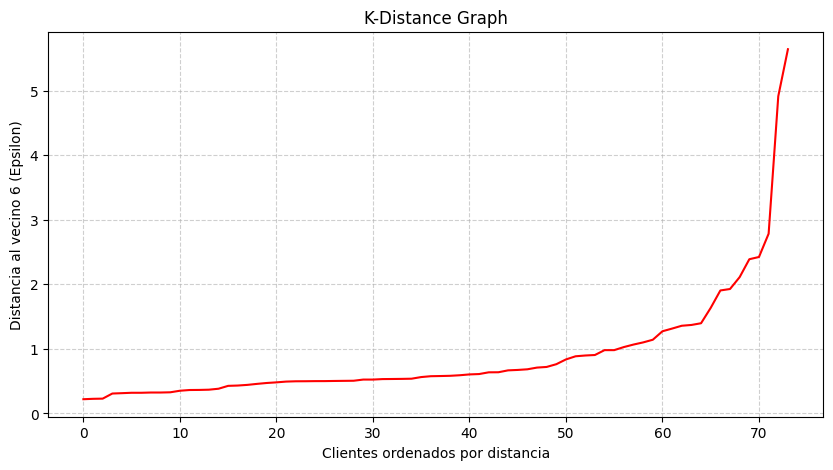

In [8]:
neighbors = NearestNeighbors(n_neighbors=6)
model_nbrs = neighbors.fit(df_pca)

distances, indices = model_nbrs.kneighbors(df_pca)
distancias_ordenadas = np.sort(distances[:, 6-1])

plt.figure(figsize=(10, 5))
plt.plot(distancias_ordenadas, color='red')
plt.title("K-Distance Graph")
plt.xlabel("Clientes ordenados por distancia")
plt.ylabel("Distancia al vecino 6 (Epsilon)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Lo que hicimos fue usar una herramienta llamada k-Distance para no empezar a ciegas buscando la épsilon de DBSCAN y tener un punto de partida. Consiste en buscar al k-ésimo vecino más cercano (k suele ser dimensión x 2) de cada cliente, después ordenamos las distancias de menor a mayor y en la gráfica buscamos la distancia en la que la densidad disminuye de manera más rápida (curvas marcadas). Así podemos darnos una idea de que épsilon mantiene una buena densidad. En la anterior gráfica podemos ver que aproximadamente en 1.2 hay una curva pronunciada que parece un valor candidato a épsilon aunque en 2 también hay una curva muy pronunciada. Dependiendo de qué épsilon usemos DBSCAN podrá ser muy estricto con lo que considera un área densa o admitir ruido en los cluster. Podemos intentar con épsilon = 1.2 aunque probaremos varios hiperparámetros en cada run de MLflow.

In [9]:
mlflow.set_tracking_uri("sqlite:///../mlflow.db")
mlflow.set_experiment("DBSCAN Northwind clientes")

with mlflow.start_run(run_name="DBSCAN eps 0.5 samples 4 (Bueno)"):

    mlflow.log_param("epsilon", 0.5)
    mlflow.log_param("Min_samples", 4)

    dbscan = DBSCAN(eps=0.5, min_samples=4)
    dbscan_clusters = dbscan.fit_predict(df_pca)

    n_clusters = len(set(dbscan_clusters)) - (1 if -1 in dbscan_clusters else 0)
    n_noise = list(dbscan_clusters).count(-1)
    if n_clusters > 1:
        score = silhouette_score(df_pca, dbscan_clusters)

        mlflow.log_metric("Silhouette socre", score)

    mlflow.log_metric("Número de clusters", n_clusters)
    mlflow.log_metric("Ruído", n_noise)



Entrenamos el modelo y usamos como métricas el número de clusters, el ruido y Solhouette score para medir la integridad de los clusters y cuantos datos quedan fuera. Registramos cada run en mlflow para llevar un registro de cada hiperparámetro que probamos y comparar las métricas. El modelo que dio mejores resultados fue el que tenía épsilon de 0.5 y min_samples de 4. Este modelo arrojó 2 clusters, 25 datos de ruido y un Silhouette score de 0.24. Con este modelo podemos segmentar a los clientes en dos grupos y los clientes que queden fuera son clientes especiales donde conviene estudiar caso por caso, pero en general son clientes importantes a los que puede tratarse de forma especial.

In [10]:
dataset["Cluster"] = dbscan_clusters

fig = px.scatter_3d(df_pca, x='PC1', y='PC2', z='PC3', opacity=0.7, template='plotly_dark',
                    color=dataset["Cluster"].astype(str), title="Clusters DBSCAN", 
                    labels={'0': 'PC1', '1': 'PC2', '2': 'PC3'}, color_discrete_sequence=px.colors.qualitative.Safe)

fig.update_traces(marker=dict(size=4))

fig.show()

En la gráfica podemos ver que efectivamente los valores ruidosos se encuentran más hacia las ramificaciones de la estructura y aparecen en áreas donde alguna variable es muy grande. También notemos que el cluster 0 se encuentra más alrededor de origen (la media de cada variable) y el cluster 1 ligeramente por debajo de la media en cada eje.

In [11]:
info_cluster = dataset.groupby('Cluster').agg({
    'Monto': 'mean',
    'UnidadesCompradas': 'mean',
    'NumeroDeOrdenes': 'mean',
    'TicketPromedio': 'mean',
    'DiversidadCategorias': 'mean',
    'Cluster': 'count'
}).rename(columns={'Cluster': 'Total_Clientes'})

print(dataset.describe())

print(info_cluster)

       UnidadesCompradas         Monto  NumeroDeOrdenes  TicketPromedio  \
count          74.000000     74.000000        74.000000       74.000000   
mean          172.202703   5221.949054         2.648649      633.994561   
std           223.491410   6747.855188         1.801312      596.673963   
min             2.000000     62.460000         1.000000       55.500000   
25%            45.750000    950.142500         1.000000      277.330000   
50%            97.500000   2381.500000         2.000000      493.437500   
75%           189.750000   5756.100000         3.000000      751.576786   
max          1418.000000  35631.210000        10.000000     4010.187500   

       DiversidadCategorias    Cluster  
count             74.000000  74.000000  
mean               4.108108   0.202703  
std                2.057845   0.921282  
min                1.000000  -1.000000  
25%                2.000000  -1.000000  
50%                4.000000   1.000000  
75%                6.000000   1.00000

Con la información obtenida de cada cluster notemos que el cluster 1 es en donde se concentran la mayoría de clientes, con 40, también notemos que en este cluster variables como Monto, Unidades compradas, Número de órdenes, Ticket promedio y Diversidad de categorías están por debajo del promedio y representan a un sector de clientes con compras esporádicas, que no compran mucho en cada compra, o muy de nicho en el tipo de productos que compran. Después tenemos el cluster 0, el más pequeño, que tiene 9 clientes. Este cluster representa a los clientes que se mantienen en valores cercanos a la media, compran con cierta regularidad, compran el valor esperado y mantienen cierta variedad en lo que compran. Después están los clientes atípicos, tenemos 25. Estos clientes varían en cuanto a cuantas ordenes hacen, cuanto suelen gastar por orden, o la diversidad de los productos que compran, pero son clientes que compran muchas unidades y han gastado mucho dinero en compras. Son clientes que representan una gran parte de las ventas y conviene mantenerlos constantes o retenerlos por lo que se debe estudiar caso por caso cada uno de ellos.  

In [12]:
tabla_contingencia = pd.crosstab(dataset["Pais"], dataset["Cluster"])

chi2, p_val, dof, expected = chi2_contingency(tabla_contingencia)

print("Estadístico Chi-cuadrado", chi2)
print("P-Value", p_val)
print("Grados de libertad: ", dof)
      
if p_val < 0.05:
    print("\nRESULTADO SIGNIFICATIVO: Existe una relación entre el País y el Cluster.")
    print("El comportamiento de compra NO es uniforme en todos los países.")
else:
    print("\nRESULTADO NO SIGNIFICATIVO: No hay evidencia de relación.")
    print("La distribución de clientes en los clusters es similar en todos los países.")



Estadístico Chi-cuadrado 36.479177689594366
P-Value 0.6295414470451726
Grados de libertad:  40

RESULTADO NO SIGNIFICATIVO: No hay evidencia de relación.
La distribución de clientes en los clusters es similar en todos los países.


Aplicamos una prueba chi-cuadrado para para evaluar la relación entre nuestros clusters y los países de origen de los clientes. Dado que el p-valor es de 0.629 en nuestra prueba podemos concluir que no existe una dependencia entre el país y el tipo de cliente. Esto sugiere que las estrategias de marketing pueden estandarizarse a nivel internacional, ya que los perfiles de clientes son consistentes en todos los mercados.

In [13]:
print(dataset)

                         NombreCliente  UnidadesCompradas     Monto  \
0                         Ernst Handel               1418  35631.21   
1                       Mère Paillarde                422  23362.60   
2                   Save-a-lot Markets                775  22500.06   
3           Rattlesnake Canyon Grocery                573  18421.42   
4                           QUICK-Stop                839  18178.80   
..                                 ...                ...       ...   
69              Océano Atlántico Ltda.                 24    399.00   
70                     Du monde entier                 13    336.00   
71          Centro comercial Moctezuma                 11    126.00   
72  Ana Trujillo Emparedados y helados                  6    111.00   
73                      Franchi S.p.A.                  2     62.46   

    NumeroDeOrdenes  TicketPromedio       Pais  DiversidadCategorias  Cluster  
0                10     1018.034571    Austria                     